<a href="https://colab.research.google.com/github/nayanees6607/ecabsd_temp/blob/main/ECABSD_V2_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#1a73e8;color:white;padding:20px 24px;border-radius:8px;margin-bottom:8px;">
  <h1 style="margin:0;font-size:1.8em;">🧬 ECABSD v2 — GPU Training on BM5</h1>
  <p style="margin:6px 0 0;opacity:0.9;">Equivariant Cross-Attention Binding Site Detection · CrossPPI Architecture</p>
</div>

> **Run cells top to bottom. Do not skip any cell.**

| Step | What it does |
|------|-------------|
| 1 | Verify GPU is allocated |
| 2 | Install all dependencies |
| 3 | Clone latest code from GitHub |
| 4 | Download BM5-clean raw PDB data |
| 5 | Build processed graph files (23-dim features) |
| 6 | Train the full model (200 epochs) |
| 7 | Evaluate on held-out test set + print graded metrics |
| 8 | Plot training curves |
| 9 | Save everything to Google Drive |

---
## Step 1 — Verify GPU

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "❌ No GPU detected!\n"
        "Go to: Runtime → Change runtime type → Hardware accelerator → GPU"
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ GPU  : {gpu_name}")
print(f"   VRAM : {gpu_mem:.1f} GB")
print(f"   CUDA : {torch.version.cuda}")
print(f"   PyTorch : {torch.__version__}")

✅ GPU  : Tesla T4
   VRAM : 15.6 GB
   CUDA : 12.8
   PyTorch : 2.11.0+cu128


---
## Step 2 — Install Dependencies

In [2]:
print("Installing packages (≈60s first time)...")
!pip install -q torch_geometric biopython pyyaml pydssp tqdm scikit-learn matplotlib seaborn fair-esm

import torch_geometric, Bio, yaml, pydssp, sklearn
import torch
try:
    torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])
except Exception:
    pass
print(f"✅ torch_geometric {torch_geometric.__version__}")
print(f"✅ biopython       {Bio.__version__}")
print(f"✅ scikit-learn    {sklearn.__version__}")
print("✅ All dependencies ready")

Installing packages (≈60s first time)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.2 MB/s eta 0:00:00
✅ torch_geometric 2.7.0
✅ biopython       1.87
✅ scikit-learn    1.6.1
✅ All dependencies ready


---
## Step 3 — Clone Repository

In [3]:
import os
import shutil

REPO_URL = "https://github.com/nayanees6607/ecabsd_temp.git"
REPO_DIR = "/content/ecabsd_temp"

if os.path.exists(REPO_DIR):
    print("Removing old repository contents to ensure a fresh clone...")
    %cd /content
    shutil.rmtree(REPO_DIR, ignore_errors=True)

print("Cloning repository...")
!git clone {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}

# Verify key files
print("\n📁 File check:")
for f in ["train.py", "evaluate.py", "config.yaml",
          "models/ecabsd_model.py", "models/cross_attention.py",
          "models/graph_construction.py", "scripts/prepare_db5.py"]:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"   {status}  {f}")

# Config dimension check (prevents the 23 vs 33 crash)
import yaml as _yaml
cfg = _yaml.safe_load(open("config.yaml"))
print("\n📋 Config check:")
print(f"   input_dim        = {cfg['model']['input_dim']}   (must be 23 or 983)")
print(f"   edge_feature_dim = {cfg['model']['edge_feature_dim']}   (must be 4)")
print(f"   hidden_dim       = {cfg['model']['hidden_dim']}")
print(f"   cross_attn_layers= {cfg['model'].get('num_cross_attn_layers', '?')}")
print(f"   loss             = {cfg['training']['loss']}")
print(f"   learning_rate    = {cfg['training']['learning_rate']}")

assert cfg['model']['input_dim'] in [23, 983],  "❌ input_dim must be 23 or 983!"
assert cfg['model']['edge_feature_dim'] == 4,    "❌ edge_feature_dim must be 4!"
assert cfg["model"]["hidden_dim"] in [128, 256], "❌ hidden_dim MUST be 128 or 256!"
assert cfg["training"]["focal_alpha"] in [0.65, 0.75], "❌ focal_alpha MUST be 0.65 or 0.75!"
print("\n✅ Config dimensions and updates verified")


Cloning repository...
Cloning into '/content/ecabsd_temp'...
remote: Enumerating objects: 3431, done.
remote: Counting objects: 100% (679/679), done.
remote: Compressing objects: 100% (214/214), done.
remote: Total 3431 (delta 533), reused 591 (delta 456), pack-reused 2752 (from 1)
Receiving objects: 100% (3431/3431), 202.69 MiB | 15.70 MiB/s, done.
Resolving deltas: 100% (2126/2126), done.
Updating files: 100% (2713/2713), done.
/content/ecabsd_temp

📁 File check:
   ✅  train.py
   ✅  evaluate.py
   ✅  config.yaml
   ✅  models/ecabsd_model.py
   ✅  models/cross_attention.py
   ✅  models/graph_construction.py
   ✅  scripts/prepare_db5.py

📋 Config check:
   input_dim        = 23   (must be 23 or 983)
   edge_feature_dim = 4   (must be 4)
   hidden_dim       = 128
   cross_attn_layers= 1
   loss             = combined
   learning_rate    = 0.0003

✅ Config dimensions and updates verified


---
## Step 4 — Download BM5-Clean PDB Data

In [4]:
BM5_DIR      = "/content/ecabsd_temp/data/BM5-clean"
HADDOCK_DIR  = BM5_DIR + "/HADDOCK-ready"

if os.path.exists(HADDOCK_DIR) and len(os.listdir(HADDOCK_DIR)) > 10:
    n = len([d for d in os.listdir(HADDOCK_DIR) if os.path.isdir(os.path.join(HADDOCK_DIR, d))])
    print(f"✅ BM5-clean already downloaded ({n} complexes found)")
else:
    print("Downloading BM5-clean from GitHub (~500 MB)...")
    !git clone https://github.com/haddocking/BM5-clean.git {BM5_DIR}
    n = len([d for d in os.listdir(HADDOCK_DIR) if os.path.isdir(os.path.join(HADDOCK_DIR, d))])
    print(f"✅ Downloaded {n} complexes")

Cloning into '/content/ecabsd_temp/data/BM5-clean'...
remote: Enumerating objects: 14389, done.
remote: Counting objects: 100% (3410/3410), done.
remote: Compressing objects: 100% (1424/1424), done.
remote: Total 14389 (delta 2371), reused 2825 (delta 1981), pack-reused 10979 (from 1)
Receiving objects: 100% (14389/14389), 130.68 MiB | 13.93 MiB/s, done.
Resolving deltas: 100% (9477/9477), done.
Updating files: 100% (7856/7856), done.
✅ Downloaded 233 complexes


---
## Step 5 — Build Processed Graph Files

> Processed `.pt` files are **not stored in the repo** (gitignored).  
> This step builds them fresh with the correct **23-dim node features** and **4-dim edge features**.  
> It takes 5–10 minutes and only needs to run once per Colab session.

In [5]:
import os
import glob
import torch
import yaml

PROCESSED_DIR = "/content/ecabsd_temp/data/db5_processed"
SPLITS_CSV    = "/content/ecabsd_temp/data/db5_splits.csv"

# Load config to check if ESM is expected
use_esm = False
if os.path.exists("config.yaml"):
    try:
        with open("config.yaml", "r") as f:
            cfg = yaml.safe_load(f)
        use_esm = cfg.get("model", {}).get("use_esm", False)
    except Exception:
        pass

existing_pt = glob.glob(f"{PROCESSED_DIR}/*.pt")

# Check for dimension consistency to handle switching between ESM and non-ESM modes
if existing_pt:
    try:
        sample_graph = torch.load(existing_pt[0], map_location="cpu", weights_only=False)
        feat_dim = sample_graph.x.shape[1]
        expected_dim = 983 if use_esm else 23
        if feat_dim != expected_dim:
            print(f"⚠️ Feature dimension mismatch! Found {feat_dim}-dim, expected {expected_dim}-dim (ESM={use_esm}). Clearing old graphs...")
            for f in existing_pt:
                os.remove(f)
            existing_pt = []
    except Exception as e:
        print(f"⚠️ Error checking processed files: {e}. Clearing to rebuild.")
        for f in existing_pt:
            os.remove(f)
        existing_pt = []

if existing_pt:
    print(f"✅ {len(existing_pt)} processed graph files found. Skipping preparation.")
else:
    print("No processed files found — building from scratch...")
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    %cd /content/ecabsd_temp
    !python scripts/prepare_db5.py \
        --db5-dir data/BM5-clean/HADDOCK-ready \
        --output-dir data/db5_processed \
        --threads 2


No processed files found — building from scratch...
/content/ecabsd_temp
[ECABSD] Processing 230 DB5 structures using 2 processes...
Processing DB5: 100% 230/230 [01:07<00:00,  3.42it/s]
  DB5 Dataset Preparation Complete
  Complexes processed:  229
  Total Chains:         449
  Errors:               11

  [ERROR LOG (First 5)]
    - 1AZS_A: 'B'
    - 1AZS_B: 'B'
    - 1DE4_B: Chain B: 1266 residues — above maximum 800
    - 1EXB_A: Chain A: 1300 residues — above maximum 800
    - 1N2C_A: Chain A: 1979 residues — above maximum 800
  Train/Val/Test split: 160 / 34 / 35 complexes
  Splits CSV:           data/db5_splits.csv


---
## Step 6 — Train the Model

**Architecture:** 4-layer GCN encoder → SE(3)-inspired refinement → 1-layer CrossAttention → LayerNorms → 2-layer classifier  
**Loss:** Combined Focal + Soft-Dice Loss  
**Optimizer:** AdamW with cosine-warmup LR schedule  
**Early stopping:** on validation F1 (patience = 80 epochs)  

Every epoch prints: `Train Loss | Train F1 | Val Loss | Val F1 | AUC-ROC | AUC-PR | LR`

In [6]:
%cd /content/ecabsd_temp
!python train.py

/content/ecabsd_temp
[ECABSD] Training on device: cuda
[ECABSD] Model parameters: 536,353
[Dataset] Loaded 2336 samples for split 'train'
[Dataset] Loaded 472 samples for split 'val'
[Dataset] Loaded 2336 samples for split 'train'
[Dataset] Loaded 472 samples for split 'val'
[ECABSD] Computing pos_weight from training data...
[ECABSD] pos_weight = 5.13
[ECABSD] Using CombinedLoss  (focal_alpha=0.65, gamma=3.0, dice_weight=0.4)
[ECABSD] LR: warmup 10 epochs → cosine 190 epochs

  ECABSD v2 Training — 200 epochs

  [chain-swap] WARNING: 145 batch(es) skipped chain-swap augmentation because chain-B labels or partner graphs were unavailable.
  [chain-swap] WARNING: 145 batch(es) used self-attention fallback and were excluded from chain-swap augmentation.
Epoch 001/200 | Train Loss: 0.3234 F1: 0.0563 | Val Loss: 0.3205 F1: 0.2903 AUC-ROC: 0.5122 AUC-PR: 0.1728 | LR: 0.000033 | 30.5s
  -> New best! val_F1=0.2903 | AUC-ROC=0.5122 | threshold=0.4248
  [chain-swap] WARNING: 139 batch(es) skippe

---
## Step 7 — Evaluate on Test Set

> The test set is **never touched** during training or threshold selection.  
> The threshold used here was found on the **validation set only** and saved in the checkpoint.

In [7]:
%cd /content/ecabsd_temp
!python evaluate.py

import json
metrics_path = "results/metrics.json"
if os.path.exists(metrics_path):
    m = json.load(open(metrics_path))

    # Grading thresholds: (acceptable, strong, excellent)
    targets = {
        "auc_roc":   (0.78, 0.84, 0.88),
        "auc_pr":    (0.40, 0.50, 0.60),
        "f1":        (0.55, 0.65, 0.72),
        "precision": (0.50, 0.65, 0.75),
        "recall":    (0.65, 0.75, 0.85),
        "mcc":       (0.40, 0.55, 0.65),
        "accuracy":  (0.78, 0.85, 0.90),
    }

    print("\n" + "="*56)
    print("  ECABSD v2 — Test Set Results")
    print("="*56)
    print(f"  {'Metric':<12} {'Value':>7}   Grade")
    print("-"*56)
    for key, (acc, strong, exc) in targets.items():
        val = m.get(key)
        if val is None:
            continue
        if val >= exc:      grade = "🏆 Excellent"
        elif val >= strong: grade = "✅ Strong"
        elif val >= acc:    grade = "🆗 Acceptable"
        else:               grade = "⚠️  Weak"
        print(f"  {key:<12} {val:>7.4f}   {grade}")
    print("="*56)
    print(f"  Samples:   {m.get('num_samples', '?')}")
    print(f"  Positives: {m.get('num_positive', '?')}")
    print(f"  Threshold: {m.get('threshold', 0.5):.4f} (from val set)")
    print("="*56)
else:
    print("⚠️  results/metrics.json not found — run evaluate.py first")

/content/ecabsd_temp
[ECABSD] Evaluating on device: cuda
[ECABSD] Loaded checkpoint from: checkpoints/best_model.pt
[ECABSD] Using saved threshold: 0.6227
[Dataset] Loaded 470 samples for split 'test'
  [Threshold] Using val-optimised threshold: 0.6227

  ECABSD Evaluation Results
                   accuracy: 0.8634
                  precision: 0.5621
                     recall: 0.6003
                         f1: 0.5806
                        mcc: 0.4994
                  threshold: 0.6227
                num_samples: 97244
               num_positive: 15320
     num_predicted_positive: 16360
                    auc_roc: 0.8536
                     auc_pr: 0.6126

  Metrics saved to: results/metrics.json
  Confusion matrix saved to: results/confusion_matrix.png

  ECABSD v2 — Test Set Results
  Metric         Value   Grade
--------------------------------------------------------
  auc_roc       0.8536   ✅ Strong
  auc_pr        0.6126   🏆 Excellent
  f1            0.5806   🆗 Accepta

---
## Step 8 — Plot Training Curves

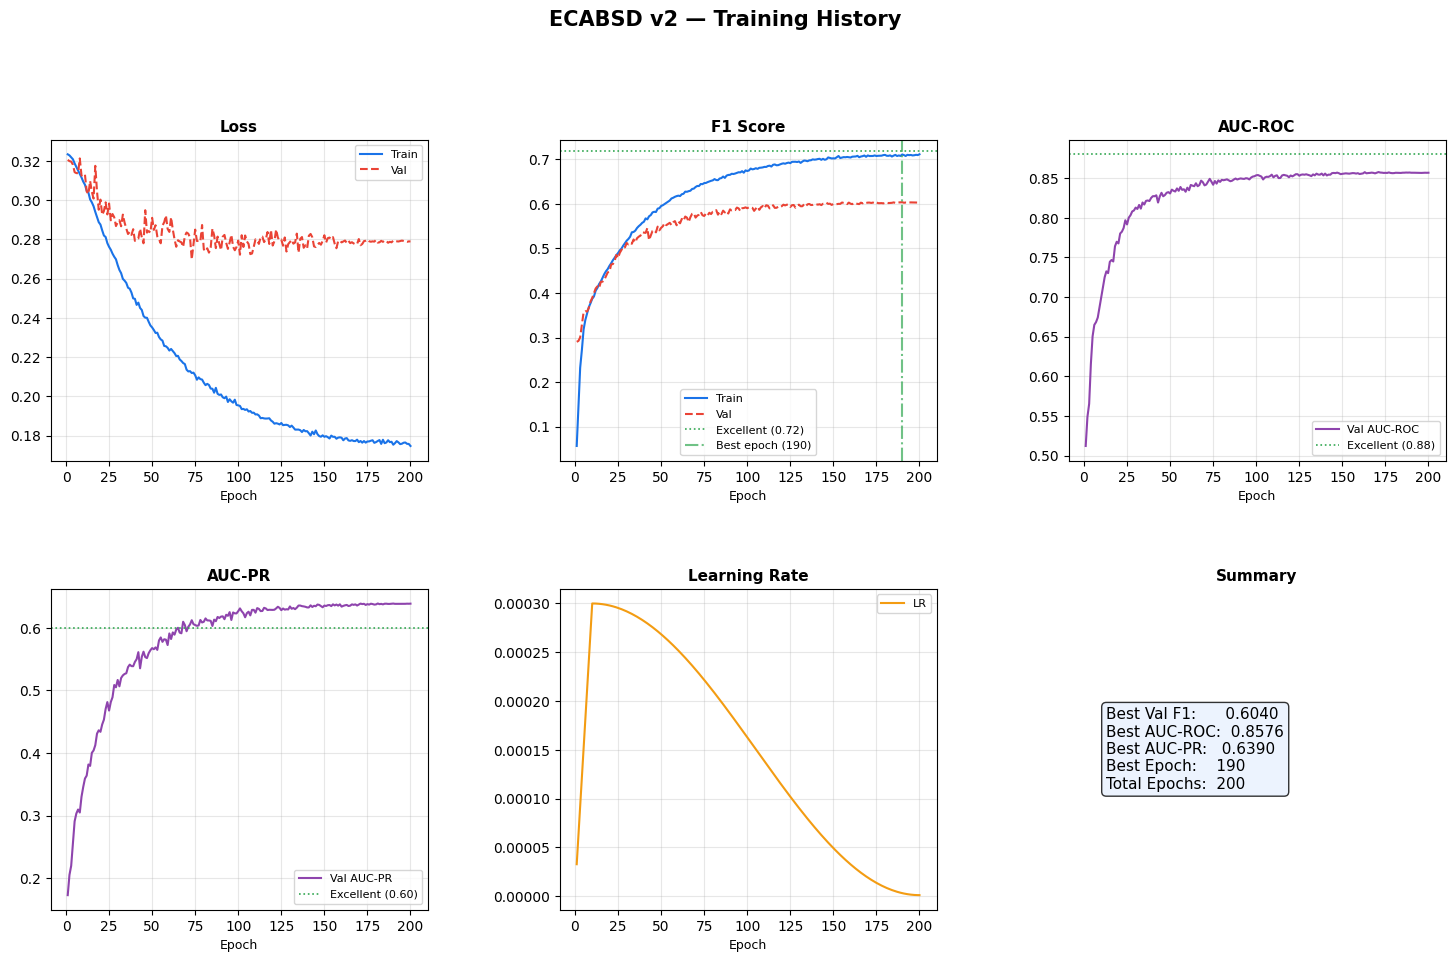

✅ Saved to results/training_curves.png


In [8]:
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

hist     = json.load(open("logs/training_history.json"))
epochs   = [h["epoch"]                    for h in hist]
tr_loss  = [h["train"]["loss"]            for h in hist]
val_loss = [h["val"]["loss"]              for h in hist]
tr_f1    = [h["train"]["f1"]              for h in hist]
val_f1   = [h["val"]["f1"]               for h in hist]
val_auc  = [h["val"].get("auc_roc", 0)   for h in hist]
val_pr   = [h["val"].get("auc_pr",  0)   for h in hist]
lrs      = [h["lr"]                       for h in hist]

fig = plt.figure(figsize=(18, 10))
fig.suptitle("ECABSD v2 — Training History", fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

BLUE, RED, GREEN, PURPLE = "#1a73e8", "#ea4335", "#34a853", "#8e44ad"

def plot(ax, title, y1, y2=None, y1_label="Train", y2_label="Val",
         hline=None, hline_label="", color1=BLUE, color2=RED):
    ax.plot(epochs, y1, label=y1_label, color=color1, linewidth=1.5)
    if y2 is not None:
        ax.plot(epochs, y2, label=y2_label, color=color2, linestyle="--", linewidth=1.5)
    if hline is not None:
        ax.axhline(hline, color=GREEN, linestyle=":", linewidth=1.2, label=hline_label)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plot(fig.add_subplot(gs[0, 0]), "Loss",    tr_loss, val_loss)
plot(fig.add_subplot(gs[0, 1]), "F1 Score", tr_f1,  val_f1,  hline=0.72, hline_label="Excellent (0.72)")
plot(fig.add_subplot(gs[0, 2]), "AUC-ROC", val_auc, color1=PURPLE, y1_label="Val AUC-ROC",
     hline=0.88, hline_label="Excellent (0.88)")
plot(fig.add_subplot(gs[1, 0]), "AUC-PR",  val_pr,  color1=PURPLE, y1_label="Val AUC-PR",
     hline=0.60, hline_label="Excellent (0.60)")
plot(fig.add_subplot(gs[1, 1]), "Learning Rate", lrs, color1="#f39c12", y1_label="LR")

# Best epoch marker
best_epoch = val_f1.index(max(val_f1))
ax_f1 = fig.get_axes()[1]
ax_f1.axvline(epochs[best_epoch], color=GREEN, linestyle="-.", alpha=0.7,
              label=f"Best epoch ({epochs[best_epoch]})")
ax_f1.legend(fontsize=8)

# Summary box
ax_sum = fig.add_subplot(gs[1, 2])
ax_sum.axis("off")
best_f1  = max(val_f1)
best_auc = max(val_auc)
best_pr  = max(val_pr)
summary_text = (
    f"Best Val F1:      {best_f1:.4f}\n"
    f"Best AUC-ROC:  {best_auc:.4f}\n"
    f"Best AUC-PR:   {best_pr:.4f}\n"
    f"Best Epoch:    {epochs[best_epoch]}\n"
    f"Total Epochs:  {len(epochs)}"
)
ax_sum.text(0.1, 0.5, summary_text, transform=ax_sum.transAxes,
            fontsize=11, verticalalignment="center",
            bbox=dict(boxstyle="round", facecolor="#e8f0fe", alpha=0.8))
ax_sum.set_title("Summary", fontsize=11, fontweight="bold")

os.makedirs("results", exist_ok=True)
plt.savefig("results/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to results/training_curves.png")

---
## Step 9 — Save to Google Drive

In [9]:
from google.colab import drive
import shutil

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/ECABSD_v2"
os.makedirs(DRIVE_DIR, exist_ok=True)

files_to_save = [
    ("checkpoints/best_model.pt",    "best_model.pt"),
    ("logs/training_history.json",   "training_history.json"),
    ("results/metrics.json",         "metrics.json"),
    ("results/training_curves.png",  "training_curves.png"),
    ("results/confusion_matrix.png", "confusion_matrix.png"),
    ("config.yaml",                  "config.yaml"),
]

print(f"Saving to {DRIVE_DIR}...")
for src, dst in files_to_save:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_DIR, dst))
        print(f"  ✅ {dst}")
    else:
        print(f"  ⚠️  {src} not found")

print(f"\n🎉 Done! Files saved to Google Drive → ECABSD_v2/")

ValueError: mount failed